In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

,blue_probs,red_probs,pred_winner,winner,correct_pred,event_date,fighter_red,fighter_blue,open_red,open_blue,...,red_fighter_odds,blue_fighter_odds,fav_counts_red,dog_counts_red,fav_counts_blue,dog_counts_blue,prob_winner,winner_odds,choice_fighter_bet,Date
0,0.332588,0.667412,1.0,1.0,1,2023-06-03,alex caceres,daniel pineda,-190.0,165.0,...,Alex Caceres,Daniel Pineda,11,17,3,9,0.667412,-190.0,-190.0,2023-06-03
1,0.359954,0.640046,1.0,0.0,0,2023-06-03,kai kara france,amir albazi,-205.0,175.0,...,Kai Kara-France,Amir Albazi,8,3,3,2,0.640046,175.0,-205.0,2023-06-03
2,0.404423,0.595577,1.0,1.0,1,2023-06-03,philipe lins,maxim grishin,-105.0,-115.0,...,Philipe Lins,Maxim Grishin,3,2,3,2,0.595577,-105.0,-105.0,2023-06-03
3,0.227231,0.772769,1.0,0.0,0,2023-06-10,miranda maverick,jasmine jasudavicius,-225.0,190.0,...,Miranda Maverick,Jasmine Jasudavicius,5,2,2,2,0.772769,190.0,-225.0,2023-06-10
4,0.631437,0.368563,0.0,1.0,0,2023-06-10,kyle nelson,blake bilder,180.0,-210.0,...,Kyle Nelson,Blake Bilder,1,6,1,1,0.631437,180.0,-210.0,2023-06-10


In [16]:
def american_to_decimal(odds):
    return np.where(odds > 0, odds / 100 + 1, 100 / np.abs(odds) + 1)

def sample_true_probability(p_hat, ece, ece_inflate=1.5, k_min=5, k_max=100):
    """
    Sample a 'true' win probability given model belief p_hat and ECE.
    """

    # Inflate ECE for OOS risk
    ece_eff = ece * ece_inflate

    # Shrink toward 0.5 (mean calibration)
    shrink = max(0.0, 1.0 - 2.0 * ece_eff)
    p_cal = 0.5 + shrink * (p_hat - 0.5)

    # Map ECE -> Beta concentration
    k = 1.0 / (ece_eff ** 2 + 1e-6)
    k = np.clip(k, k_min, k_max)

    alpha = p_cal * k
    beta_ = (1.0 - p_cal) * k

    return np.random.beta(alpha, beta_)

def monte_carlo_units(
    df,
    red_prob_c, blue_prob_c,
    red_odds_c, blue_odds_c,
    dec_red, dec_blue,
    dec_fair_red, dec_fair_blue,
    odds_type,
    n_sims,
    ece=.03,
    ece_inflate=1.5,
    k_min=5,
    k_max=100
):

    # Add decimal odds
    # df['red_dec'] = american_to_decimal(df[red_odds_c])
    # df['blue_dec'] = american_to_decimal(df[blue_odds_c])
    df['red_dec'] = df[dec_red]
    df['blue_dec'] = df[dec_blue]

    df['red_dec_fair'] = df[dec_fair_red]
    df['blue_dec_fair'] = df[dec_fair_blue]

    # Expected value for each side
    df['ev_red'] = (df['red_dec'] - 1) * df[red_prob_c] - (1 - df[red_prob_c])
    df['ev_blue'] = (df['blue_dec'] - 1) * df[blue_prob_c] - (1 - df[blue_prob_c])


    # ---- tracking for simulation averages ----
    results = {
        "favorites_chosen": [],
        "favorites_correct": [],
        "favorites_wrong": [],
        "favorites_units": [],

        "dogs_chosen": [],
        "dogs_correct": [],
        "dogs_wrong": [],
        "dogs_units": [],

        "accuracy": [],
        "total_units": []
    }

    plt.figure(figsize=(9,6))

    for _ in range(n_sims):

        fav_chosen = fav_correct = fav_wrong = 0
        dog_chosen = dog_correct = dog_wrong = 0
        fav_units = dog_units = 0

        correct_preds = 0
        round_units = []

        for i, row in df.iterrows():

            red_prob, blue_prob = row[red_prob_c], row[blue_prob_c]
            ev_red, ev_blue = row['ev_red'], row['ev_blue']

            # Pick the predicted side (higher predicted chance)
            pred = "red" if red_prob > blue_prob else "blue"
            win_prob = red_prob if pred == "red" else blue_prob
            win_dec  = (row['red_dec'] - 1) if pred == "red" else (row['blue_dec'] - 1)

            # Skip if EV is negative for the chosen side
            if (pred == "red" and ev_red <= 0) or (pred == "blue" and ev_blue <= 0):
                continue

            # # Label favorite vs dog
            is_favorite = (row['red_dec'] <= row['blue_dec'] and pred == "red") or \
                          (row['blue_dec'] < row['red_dec'] and pred == "blue")
            

            # Simulate outcome
            p_true = np.random.normal(win_prob, ece)
            outcome = np.random.rand() <= p_true

            # Track favorites vs dogs
            if is_favorite:
                fav_chosen += 1
                if outcome:
                    fav_correct += 1
                    fav_units += win_dec
                else:
                    fav_wrong += 1
                    fav_units -= 1 
            elif not is_favorite:
                dog_chosen += 1
                if outcome:
                    dog_correct += 1
                    dog_units += win_dec
                else:
                    dog_wrong += 1
                    dog_units -= 1
            else: 
                print('ERROR WITH FAV DOG')

            # General sim tracking
            round_units.append(win_dec if outcome else -1)
            if outcome:
                correct_preds += 1

        # Save results for this simulation
        results["favorites_chosen"].append(fav_chosen)
        results["favorites_correct"].append(fav_correct)
        results["favorites_wrong"].append(fav_wrong)
        results["favorites_units"].append(fav_units)

        results["dogs_chosen"].append(dog_chosen)
        results["dogs_correct"].append(dog_correct)
        results["dogs_wrong"].append(dog_wrong)
        results["dogs_units"].append(dog_units)

        results["accuracy"].append(correct_preds / max(fav_chosen + dog_chosen, 1))
        results["total_units"].append(sum(round_units))

        # Plot running units for this sim
        plt.plot(np.cumsum(round_units), alpha=0.12)

    # ---- Fix: total_units is already FINAL units per sim ----
    sim_units = np.array(results['total_units'])
    final_results = sim_units

    # ---- 95% Confidence Interval ----
    mean_final = np.mean(final_results)
    std_final = np.std(final_results, ddof=1)
    ci95 = 1.96 * std_final / np.sqrt(n_sims)
    lower_ci = mean_final - ci95
    upper_ci = mean_final + ci95

    # ---- Probability of loss ----
    prob_loss = (final_results < 0).mean() * 100

    avg_accuracy = np.mean(results['accuracy']) * 100
    print({key: np.mean(vals) for key, vals in results.items()})

    # ---- Plot title ----
    plt.title(f'Odds={odds_type.upper()}, Avg Units {mean_final:.2f}, Mean 95% CI=[{lower_ci:.2f}, {upper_ci:.2f}], '
              f'Prob Loss={prob_loss:.2f}%, sims={n_sims}')
    plt.show()

    df_results = pd.DataFrame(results)
    df_results.to_csv(fr"C:\Users\jcmar\my_files\SportsBetting\models\lr_stats_save\{odds_type}_monte_carlo_df.csv", index=False)
    plt.savefig(fr"C:\Users\jcmar\my_files\SportsBetting\models\lr_stats_save\{odds_type}_monte_carlo.png", dpi=300, bbox_inches='tight')

    return mean_final, (lower_ci, upper_ci), prob_loss



In [ ]:

def monte_carlo_conformal(df_tcp, n_sims=5000, base_bet=1.0):

    df = df_tcp 
    total_units = []

    for _ in range(n_sims):

        units = 0

        for _, row in df.iterrows():

            # skip uncertain predictions (set size = 2)
            if row["p_red"] >= 0.1 and row["p_blue"] >= 0.1:
                continue

            # identify TCP predicted side
            pred_side = "red" if row["p_red"] > row["p_blue"] else "blue"

            # model win probability
            win_prob = row["prob_red"] if pred_side == "red" else row["prob_blue"]

            # decimal odds
            win_odds = row["red_dec"] if pred_side == "red" else row["blue_dec"]

            low_prob  = 1 - max(row["p_red"], row["p_blue"])
            high_prob = max(row["p_red"], row["p_blue"])

            true_prob = np.random.uniform(low_prob, high_prob)
            outcome = np.random.rand() <= true_prob

            units += (win_odds - 1) if outcome else -1

        total_units.append(units)

    return np.array(total_units)





{'favorites_chosen': np.float64(426.0), 'favorites_correct': np.float64(311.065), 'favorites_wrong': np.float64(114.935), 'favorites_units': np.float64(40.38776489467907), 'dogs_chosen': np.float64(103.0), 'dogs_correct': np.float64(58.81), 'dogs_wrong': np.float64(44.19), 'dogs_units': np.float64(22.644239041871636), 'accuracy': np.float64(0.6991965973534973), 'total_units': np.float64(63.0320039365507)}


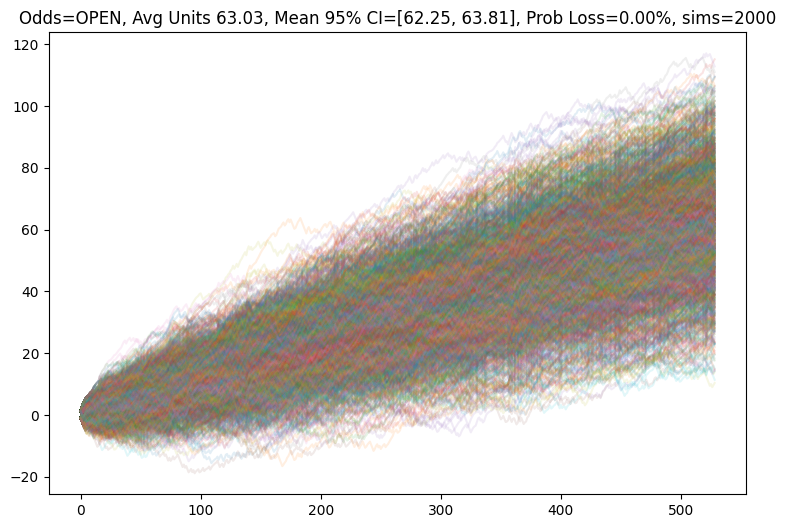

(np.float64(63.0320039365507),
 (np.float64(62.25359861394261), np.float64(63.810409259158796)),
 np.float64(0.0))

<Figure size 640x480 with 0 Axes>

In [ ]:
# df_results = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\ufc_da2_model_results_test.csv')
df_results = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\test_logit_open.csv')
monte_carlo_units(df_results,'proba_red', 'proba_blue', 'open_red', 'open_blue',
                  'dec_open_red', 'dec_open_blue','dec_fair_open_red', 'dec_fair_open_blue', 'open', 2000, ece=.08)

In [20]:
df_results_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\test_results_lr_close.csv')

{'favorites_chosen': np.float64(266.0), 'favorites_correct': np.float64(200.0025), 'favorites_wrong': np.float64(65.9975), 'favorites_units': np.float64(23.877135315141803), 'dogs_chosen': np.float64(116.0), 'dogs_correct': np.float64(66.548), 'dogs_wrong': np.float64(49.452), 'dogs_units': np.float64(35.326558963969525), 'accuracy': np.float64(0.6977761780104712), 'total_units': np.float64(59.20369427911134)}


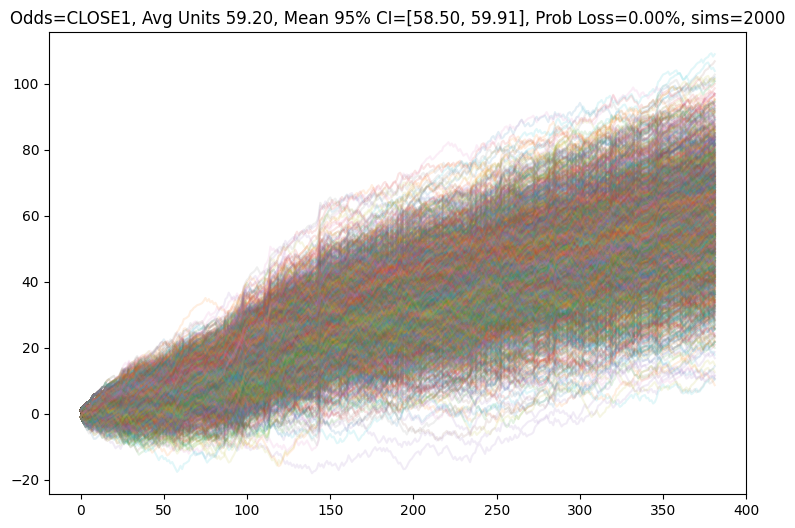

(np.float64(59.20369427911134),
 (np.float64(58.49680601946865), np.float64(59.91058253875403)),
 np.float64(0.0))

<Figure size 640x480 with 0 Axes>

In [21]:
monte_carlo_units(df_results_close1,'red_probs', 'blue_probs', 'close1_red', 'close1_blue',
                  'dec_close1_red', 'dec_close1_blue','dec_fair_close1_red', 'dec_fair_close1_blue', 'close1', 2000, ece=.04)

{'favorites_chosen': np.float64(376.0), 'favorites_correct': np.float64(276.6295), 'favorites_wrong': np.float64(99.3705), 'favorites_units': np.float64(41.803644655775294), 'dogs_chosen': np.float64(119.0), 'dogs_correct': np.float64(68.238), 'dogs_wrong': np.float64(50.762), 'dogs_units': np.float64(56.140671818106384), 'accuracy': np.float64(0.6967020202020203), 'total_units': np.float64(97.94431647388166)}


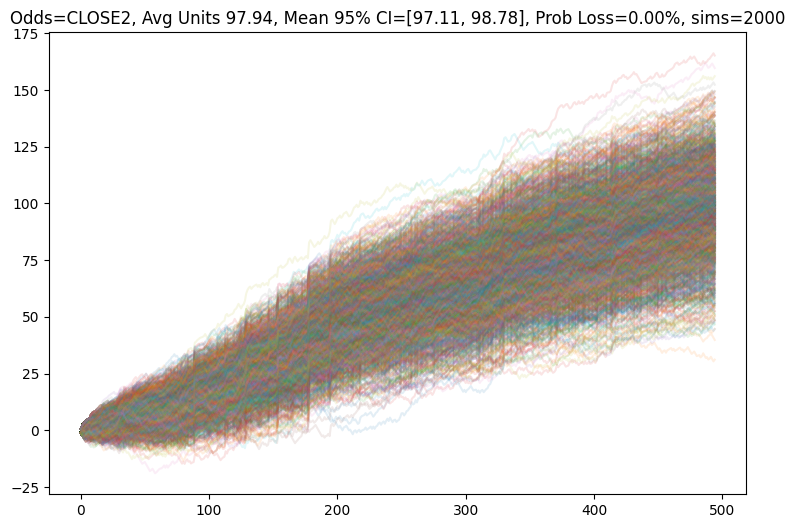

(np.float64(97.94431647388166),
 (np.float64(97.10877871921618), np.float64(98.77985422854714)),
 np.float64(0.0))

<Figure size 640x480 with 0 Axes>

In [18]:
monte_carlo_units(df_results_close1,'red_probs', 'blue_probs', 'close2_red', 'close2_blue',
                   'dec_close2_red', 'dec_close2_blue','dec_fair_close2_red', 'dec_fair_close2_blue', 'close2', 2000, ece=.05) 